Investigation of the use of discriminants derived from probability models, and compare them to the Fisher linear discriminant. The Fisher discriminant ﬁnds a projection that minimizes the sum-of-squares of data
points with their respective class means and that maximizes the diﬀerence between projected means.

In [ ]:
import numpy
import sklearn,sklearn.datasets
import sklearn.decomposition
from matplotlib import pyplot as plt

In [5]:
class FDA:
    def __init__(self):
        pass
    def fit(self,X1,X2):
        d = X1.shape[1]
        m1 = X1.mean(axis=0)
        m2 = X2.mean(axis=0)
        X = numpy.concatenate([X1,X2])
        Si = numpy.linalg.inv(numpy.cov(X.T))
        self.w = Si.dot(m2-m1)
        return self
    def predict(self,X):
        return numpy.dot(X,self.w)

I will apply discriminant analyses to the wine dataset accessible via sklearn. Specifically, I will analyse to which extent a particular cultivar (the one associated to index 0 in the dataset), can be identified from a reduced set of compositional features: Magnesium, Total phenols, Flavanoids, Nonﬂavanoid phenols.

In [ ]:
X,T = sklearn.datasets.load_wine(return_X_y=True)
X = X[:,4:8] # extract compositional features of interest
X = X - X.mean(axis=0)
X = X / X.std(axis=0)
T = 1.0*(T==0) # indicator function of the cultivar of interest
XN = X[T==0] # negative examples
XP = X[T==1] # positive examples

Before implementing the discriminant analysis, I will perform some initial data analysis. First, a two-
dimensional PCA of the data. 

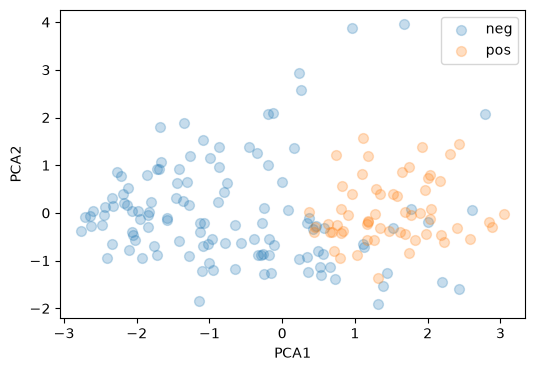

In [9]:
Xpca = sklearn.decomposition.PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(6,4))
plt.scatter(*Xpca[T==0].T,alpha=0.25,label='neg',s=50)
plt.scatter(*Xpca[T==1].T,alpha=0.25,label='pos',s=50)
plt.legend()
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

From this PCA plot, one can observe some specifics of the distribution, that suggest that a linear discriminant between the two
classes may be suboptimal. In particular, the covariance structure of both classes appears diﬀerent, speciﬁcally, the distribution of
positive instances appears to have less variance than the negative one. To verify this visual insight, I will measure
quantitatively the total variance of the two distributions.

In [10]:
def printTotalVariance(XN,XP):
    VarN = numpy.trace(numpy.cov(XN.T))
    VarP = numpy.trace(numpy.cov(XP.T))
    print('Total variance for negative class: %8.3f'%VarN)
    print('Total variance for positive class: %8.3f'%VarP)

These quantitative measurements corroborate our initial visual insight. The observation that the two distributions have diﬀerent
covariance structures motivates the use of a more powerful discriminant than the Fisher discriminant. Here, I will consider the
Gaussian-based discriminant. Specifically, one computes the log likelihood ratio of two Gaussians distributions representing each class
and then deﬁnes the discriminant to be the log-probability ratio between the data likelihoods associated to each class.

In [11]:
class QDA:
    def __init__(self):
        pass
    def fit(self,X1,X2):
        self.m1 = X1.mean(axis=0)
        self.m2 = X2.mean(axis=0)
        self.S1i = numpy.linalg.inv(numpy.cov(X1.T))
        self.S2i = numpy.linalg.inv(numpy.cov(X2.T))
        return self
    def predict(self,X):
        d1 = 0.5*((X-self.m1).dot(self.S1i)*(X-self.m1)).sum(axis=1)
        d2 = 0.5*((X-self.m2).dot(self.S2i)*(X-self.m2)).sum(axis=1)
        return d1-d2

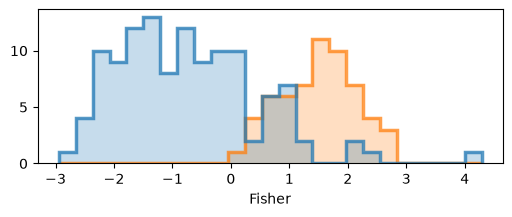

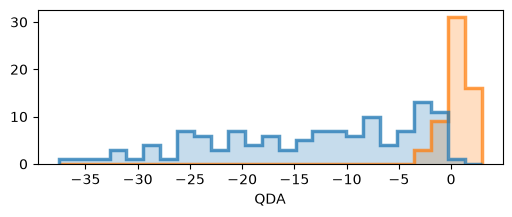

In [12]:
fda = FDA().fit(XN,XP)
qda = QDA().fit(XN,XP)
def hist(ZN,ZP,name):
    plt.figure(figsize=(6,2))
    plt.hist([ZN,ZP], color=['C0','C1'], bins=25, alpha=0.25, histtype='stepfilled')
    plt.hist([ZN,ZP], color=['C0','C1'], bins=25, alpha=0.75, histtype='step', lw=2.5)
    plt.xlabel(name)
    plt.show()

hist(fda.predict(XN), fda.predict(XP), 'Fisher')
hist(qda.predict(XN),qda.predict(XP), 'QDA')

Unlike the Fisher discriminant, the quadratic discriminant does not reduce within-class variance. However, it appears that the two classes are fairly well separable if considering separability as being on one or the other side of some threshold value. To verify this I will use the ares under the curve (AUROC) metric, which quantifies this. 

In [16]:
def printAUROC(fda,qda,X,T):
    auroc_fda = sklearn.metrics.roc_auc_score(T,fda.predict(X))
    auroc_qda = sklearn.metrics.roc_auc_score(T,qda.predict(X))
    print('AUROC-Fisher: %.3f'%auroc_fda)
    print('AUROC-QDA: %.3f'%auroc_qda)
printAUROC(fda,qda, X, T)

AUROC-Fisher: 0.942
AUROC-QDA: 0.988
